In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler 

In [12]:
df_global = pd.read_csv('data/BostonHousing.csv')

df_global = df_global.rename(columns={
    'crim': 'crime_rate',           # Уровень преступности
    'zn': 'large_lots',              # Доля земли под большие участки
    'indus': 'industry',             # Доля промышленности
    'chas': 'river',                  # У реки (Charles river)
    'nox': 'nox_conc',       # Концентрация оксидов азота
    'rm': 'rooms_avg',                # Среднее число комнат
    'age': 'old_buildings',           # Доля старых домов (до 1940)
    'dis': 'center_dist',  # Расстояние до центров занятости
    'rad': 'highway',          # Доступ к шоссе
    'tax': 'property',            # Налог на недвижимость
    'ptratio': 'pupil_teacher', # Соотношение ученики/учитель
    'b': 'black_population',    # Индекс чернокожего населения 
    'lstat': 'lower_status',  # % населения с низким статусом
    'medv': 'price'                    # ЦЕЛЬ: медианная цена дома
})


In [13]:
# Целевая переменная
X = df_global.drop('price', axis=1) # все столбцы, кроме price. axis=1 - удаляем столбец, 0 - удаляем строку
y = df_global['price'] # только price

# 1. Разделяем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
) # 0.3 данных - тест, random_state - число для рандома

# 2. Считаем медианы по каждому столбцу НА ТРЕНИРОВОЧНЫХ данных
medians = X_train.median()

# 3. Заполняем пропуски в train
X_train_filled = X_train.fillna(medians) # fillna - заплатка

# 4. Заполняем пропуски в test (ТЕМИ ЖЕ медианами!)
X_test_filled = X_test.fillna(medians) # если заполнить медианами из теста, то будет утечка данных, потому что мы будем использоваться информацию, которая нам неизвестна на момент обучения модели

# 5. Проверяем, что пропусков больше нет
# print(f"\nПропуски в train после заполнения: {X_train_filled.isnull().sum().sum()}")
# print(f"Пропуски в test после заполнения: {X_test_filled.isnull().sum().sum()}")

# 6. Обучаем модель
model = LinearRegression()
model.fit(X_train_filled, y_train) # X_train_filled - учебник, y_train - ответы

# 7. Оцениваем качество
train_score = model.score(X_train_filled, y_train)
test_score = model.score(X_test_filled, y_test)

print(f"\nR² на train: {train_score:.3f}")
print(f"R² на test:  {test_score:.3f}")


R² на train: 0.743
R² на test:  0.710


In [14]:
df_global.shape

(506, 14)

In [15]:
df_global.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   crime_rate        506 non-null    float64
 1   large_lots        506 non-null    float64
 2   industry          506 non-null    float64
 3   river             506 non-null    int64  
 4   nox_conc          506 non-null    float64
 5   rooms_avg         501 non-null    float64
 6   old_buildings     506 non-null    float64
 7   center_dist       506 non-null    float64
 8   highway           506 non-null    int64  
 9   property          506 non-null    int64  
 10  pupil_teacher     506 non-null    float64
 11  black_population  506 non-null    float64
 12  lower_status      506 non-null    float64
 13  price             506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [16]:
df_global.describe().T

,count,mean,std,min,25%,50%,75%,max
crime_rate,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
large_lots,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
industry,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
river,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
nox_conc,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
rooms_avg,501.0,6.284341,0.705587,3.56100,5.884000,6.20800,6.625000,8.7800
old_buildings,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
center_dist,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
highway,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
property,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


In [17]:
df_global.head()

,crime_rate,large_lots,industry,river,nox_conc,rooms_avg,old_buildings,center_dist,highway,property,pupil_teacher,black_population,lower_status,price
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


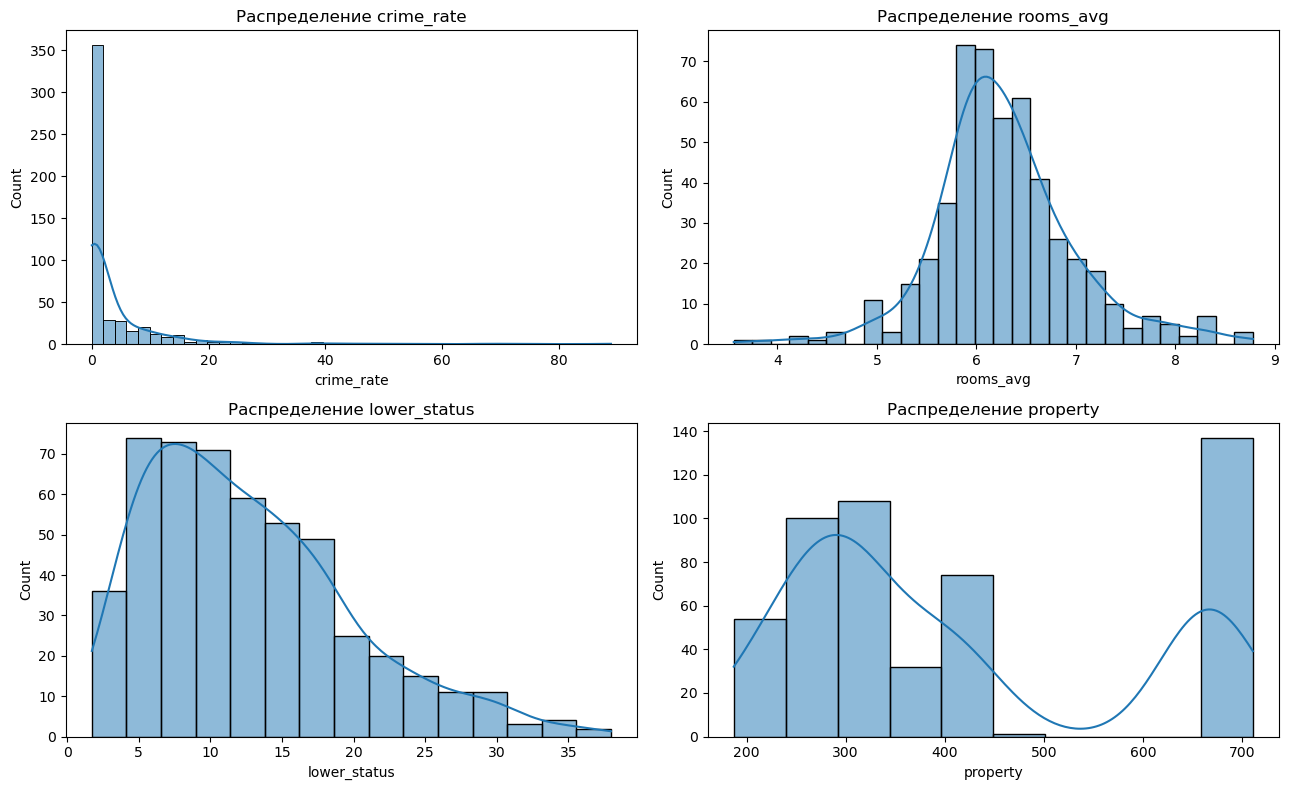

In [18]:
selected_features = ['crime_rate', 'rooms_avg', 'lower_status', 'property']

fig, axes = plt.subplots(2, 2, figsize=(13, 8)) # fig - окно целиком, axes - список из 4 графиков
axes = axes.flatten() # flatten - сплющивание в одномерный массив

for i, col in enumerate(selected_features):
    sns.histplot(df_global[col], kde=True, ax=axes[i]) # kde - линия, ax - куда рисовать
    axes[i].set_title(f'Распределение {col}')

plt.tight_layout() # чтобы графики не налезали друг на друга
plt.show()

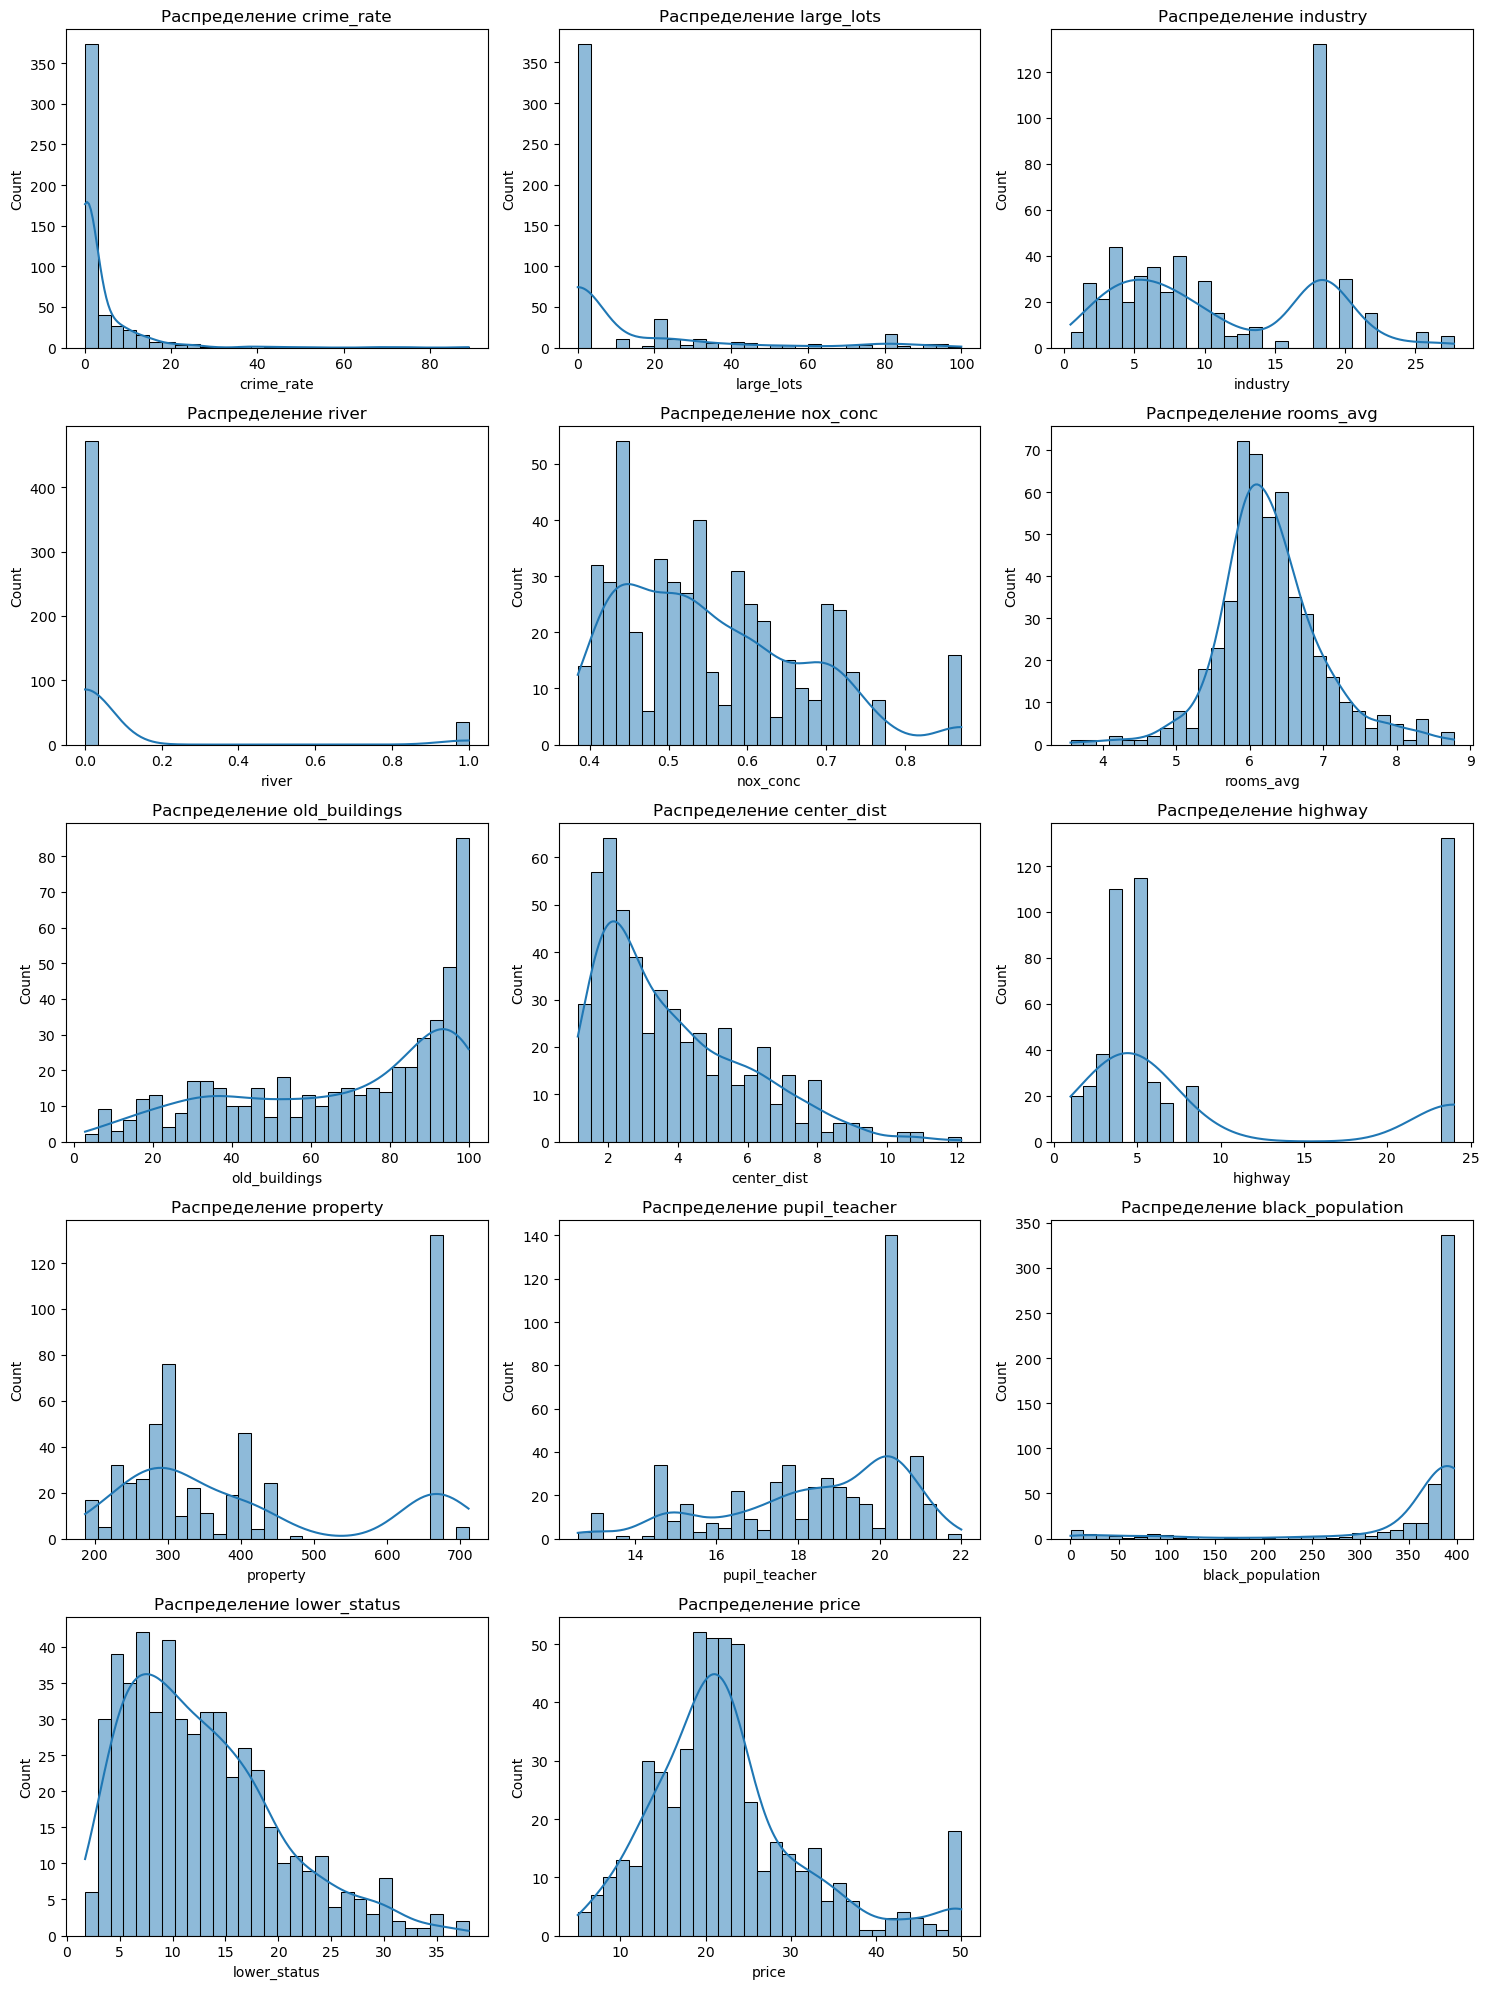

In [19]:
numeric_features = ['crime_rate', 'large_lots', 'industry', 'river',  'nox_conc', 'rooms_avg', 'old_buildings', 'center_dist', 'highway', 'property', 'pupil_teacher', 'black_population', 'lower_status', 'price']

# 1. Считаем количество признаков
n_features = len(numeric_features)
n_cols = 3  # Количество колонок в сетке
n_rows = math.ceil(n_features / n_cols) # Рассчитываем строки (округляем вверх)

# 2. Создаем фигуру с динамическим количеством строк
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten() # Превращаем матрицу в плоский список

for i, col in enumerate(numeric_features):
    sns.histplot(df_global[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Распределение {col}')

# 3. Удаляем пустые графики, если признаков меньше, чем ячеек (например, 7 признаков в сетке 3x3)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()